# Evaluasi Full Test Strict — Final WavLM LoRA

Notebook ini dibuat untuk:

1. **Load final model** hasil fine-tuning WavLM LoRA.
2. **Infer seluruh `test_strict`** dari manifest strict.
3. Menyimpan **CSV detail prediksi vs ground truth** untuk seluruh sampel.
4. Menghitung **metrik evaluasi lengkap** per trait dan agregat.
5. Membuat **visualisasi** distribusi, scatter prediksi vs label, residual, dan ringkasan metrik.
6. Menampilkan **contoh sampel terbaik dan terburuk** berdasarkan error per baris.

> Catatan:
> - Default path dibuat mengikuti pola dari `FineTuneWavLMV2.ipynb` dan `TestPersebaran.ipynb`.
> - Jika lokasi file di mesinmu berbeda, cukup edit **cell konfigurasi path** di bawah.

In [1]:
from pathlib import Path
import os
import json
import warnings
from datetime import datetime

warnings.filterwarnings(
    "ignore",
    message="Support for mismatched key_padding_mask and attn_mask is deprecated.*",
    category=UserWarning,
)

# ============================================================
# CONFIG PATH
# ============================================================
CURRENT = Path().resolve()

ROOT = CURRENT.parent
DATA = ROOT / "data"
OUTS = ROOT / "outputs"

# ===== pilih run final terbaik (ubah kalau folder final kamu beda)
DEFAULT_FINAL_DIR = OUTS / "final_retrain_lr0.0002_r4"
available_final_dirs = sorted([p for p in OUTS.glob("final_retrain_lr*_r*") if p.is_dir()])

if DEFAULT_FINAL_DIR.exists():
    FINAL_RUN_DIR = DEFAULT_FINAL_DIR
elif available_final_dirs:
    FINAL_RUN_DIR = available_final_dirs[-1]
else:
    FINAL_RUN_DIR = DEFAULT_FINAL_DIR

PT_PATH = FINAL_RUN_DIR / "final_model.pt"

# ===== kandidat manifest strict
manifest_candidates = [
    DATA / "manifest_strict_vast.csv",
    DATA / "manifest_strict.csv",
    ROOT / "output" / "split_strict" / "manifest_strict.csv",
    ROOT.parent / "output" / "split_strict" / "manifest_strict.csv",
    ROOT.parent.parent / "output" / "split_strict" / "manifest_strict.csv",
]

MANIFEST = next((p for p in manifest_candidates if p.exists()), manifest_candidates[0])

# ===== HF cache optional
HF_CACHE = DATA / "hf_cache"
if HF_CACHE.exists():
    (HF_CACHE / "hub").mkdir(parents=True, exist_ok=True)
    (HF_CACHE / "transformers").mkdir(parents=True, exist_ok=True)
    (HF_CACHE / "datasets").mkdir(parents=True, exist_ok=True)

    os.environ["HF_HOME"] = str(HF_CACHE)
    os.environ["HF_HUB_CACHE"] = str(HF_CACHE / "hub")
    os.environ["TRANSFORMERS_CACHE"] = str(HF_CACHE / "transformers")
    os.environ["HF_DATASETS_CACHE"] = str(HF_CACHE / "datasets")

os.environ["TOKENIZERS_PARALLELISM"] = "false"

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
EVAL_OUT = FINAL_RUN_DIR / f"eval_test_strict_full_{RUN_TS}"
FIG_DIR = EVAL_OUT / "figures"
EVAL_OUT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("CURRENT       :", CURRENT)
print("ROOT          :", ROOT)
print("DATA          :", DATA, "| exists:", DATA.exists())
print("OUTS          :", OUTS, "| exists:", OUTS.exists())
print("FINAL_RUN_DIR :", FINAL_RUN_DIR, "| exists:", FINAL_RUN_DIR.exists())
print("PT_PATH       :", PT_PATH, "| exists:", PT_PATH.exists())
print("MANIFEST      :", MANIFEST, "| exists:", MANIFEST.exists())
print("EVAL_OUT      :", EVAL_OUT)
print("available final dirs:", [p.name for p in available_final_dirs])

assert PT_PATH.exists(), f"Checkpoint final tidak ditemukan: {PT_PATH}"
assert MANIFEST.exists(), f"Manifest strict tidak ditemukan: {MANIFEST}"

CURRENT       : E:\tugas-akhir-qiqi\code\workspaceVastAI\notebooks
ROOT          : E:\tugas-akhir-qiqi\code\workspaceVastAI
DATA          : E:\tugas-akhir-qiqi\code\workspaceVastAI\data | exists: True
OUTS          : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs | exists: True
FINAL_RUN_DIR : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4 | exists: True
PT_PATH       : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\final_model.pt | exists: True
MANIFEST      : E:\tugas-akhir-qiqi\code\workspaceVastAI\data\manifest_strict_vast.csv | exists: True
EVAL_OUT      : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152
available final dirs: ['final_retrain_lr0.0002_r4']


In [2]:
import sys
print(sys.executable)

c:\Users\aquq1\AppData\Local\Programs\Python\Python312\python.exe


In [3]:
import torch
print(torch.__version__)


2.10.0+cpu


In [2]:
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from transformers import WavLMModel, AutoFeatureExtractor
from peft import LoraConfig, get_peft_model
from tqdm.auto import tqdm
from IPython.display import display

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

class WavLMWithHead(nn.Module):
    def __init__(self, backbone_name: str, r: int, lora_alpha: int = 32, lora_dropout: float = 0.05):
        super().__init__()
        base = WavLMModel.from_pretrained(backbone_name)

        for p in base.parameters():
            p.requires_grad = False

        lora_cfg = LoraConfig(
            r=r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=["q_proj", "v_proj"],
            bias="none",
        )
        self.backbone = get_peft_model(base, lora_cfg)

        hidden = base.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 5),
            nn.Sigmoid(),
        )

    def mean_pool(self, x, attn_mask=None):
        if attn_mask is None:
            return x.mean(dim=1)
        m = attn_mask.unsqueeze(-1).type_as(x)
        return (x * m).sum(dim=1) / (m.sum(dim=1).clamp(min=1.0))

    def forward(self, input_values, attention_mask=None):
        out = self.backbone(input_values=input_values, attention_mask=attention_mask)
        h = out.last_hidden_state

        feat_mask = None
        if attention_mask is not None:
            base = self.backbone.base_model if hasattr(self.backbone, "base_model") else self.backbone
            if hasattr(base, "_get_feature_vector_attention_mask"):
                feat_mask = base._get_feature_vector_attention_mask(h.shape[1], attention_mask)

        pooled = self.mean_pool(h, feat_mask)
        return self.head(pooled)

c:\Users\aquq1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cpu


In [3]:
# ============================================================
# LOAD CHECKPOINT
# ============================================================
ckpt = torch.load(PT_PATH, map_location="cpu")
cfg = ckpt.get("config", {})

MODEL_NAME = cfg.get("model_name", "microsoft/wavlm-base-plus")
R = int(cfg.get("r", 8))
LORA_ALPHA = int(cfg.get("lora_alpha", 32))
LORA_DROPOUT = float(cfg.get("lora_dropout", 0.05))

SR_TARGET = 16000
MAX_SEC = 15.0
MAX_LEN = int(SR_TARGET * MAX_SEC)

print("Checkpoint config:")
print(json.dumps(cfg, indent=2) if cfg else "(config kosong / minimal)")

model = WavLMWithHead(
    backbone_name=MODEL_NAME,
    r=R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
).to(DEVICE)

state = ckpt.get("model_state", ckpt.get("state_dict"))
assert state is not None, "model_state / state_dict tidak ditemukan di checkpoint"

model.load_state_dict(state, strict=True)
model.eval()

feat = AutoFeatureExtractor.from_pretrained(MODEL_NAME)

print(f"Loaded OK | model={MODEL_NAME} | r={R} | lora_alpha={LORA_ALPHA} | lora_dropout={LORA_DROPOUT}")

Checkpoint config:
{
  "model_name": "microsoft/wavlm-base-plus",
  "split": "strict",
  "lr": 0.0002,
  "r": 4,
  "seed": 42,
  "epochs": 20,
  "batch_size": 52,
  "grad_accum_steps": 1,
  "use_amp": true
}
Loaded OK | model=microsoft/wavlm-base-plus | r=4 | lora_alpha=32 | lora_dropout=0.05


In [4]:
# ============================================================
# LOAD MANIFEST + RESOLVE TEST STRICT
# ============================================================
df = pd.read_csv(MANIFEST)
print("Manifest shape:", df.shape)
print("Columns:", list(df.columns))

SPLIT_COL = "split_strict"
LABEL_COLS = ["extraversion", "neuroticism", "agreeableness", "conscientiousness", "openness"]
TRAITS = LABEL_COLS.copy()

for c in [SPLIT_COL] + LABEL_COLS:
    assert c in df.columns, f"Kolom wajib tidak ditemukan: {c}"

def resolve_audio_path(row, root: Path, data_dir: Path):
    candidates = []

    for col in ["audio_path_abs", "audio_path", "audio_out"]:
        if col in row.index and pd.notna(row[col]):
            raw = str(row[col]).strip()
            if raw:
                p = Path(raw)
                if p.is_absolute():
                    candidates.append(p)
                else:
                    candidates.extend([
                        root / raw,
                        root.parent / raw,
                        root.parent.parent / raw,
                        data_dir / raw,
                        data_dir / Path(raw).name,
                        data_dir / "preprocessed_full" / Path(raw).name,
                        data_dir / "preprocessed_full" / "preprocessed_full" / Path(raw).name,
                    ])

    # deduplicate sambil jaga urutan
    seen = set()
    uniq = []
    for p in candidates:
        s = str(p.resolve()) if p.exists() else str(p)
        if s not in seen:
            seen.add(s)
            uniq.append(p)

    for p in uniq:
        if p.exists():
            return p.resolve()

    return uniq[0].resolve() if uniq else None

df_test = df[df[SPLIT_COL] == "test"].copy().reset_index(drop=True)
assert len(df_test) > 0, "Split test_strict kosong"

df_test["resolved_audio_path"] = df_test.apply(lambda row: resolve_audio_path(row, ROOT, DATA), axis=1)
df_test["audio_exists"] = df_test["resolved_audio_path"].apply(lambda p: Path(p).exists() if p is not None else False)

print("Jumlah test_strict:", len(df_test))
print("Audio exists       :", int(df_test["audio_exists"].sum()), "/", len(df_test))

missing_df = df_test[~df_test["audio_exists"]].copy()
if len(missing_df) > 0:
    missing_path = EVAL_OUT / "missing_audio_rows.csv"
    missing_df.to_csv(missing_path, index=False)
    print("Ada audio yang belum ter-resolve. Disimpan ke:", missing_path)
    display(missing_df.head(10))
else:
    print("Semua audio test_strict berhasil di-resolve.")

Manifest shape: (9974, 15)
Columns: ['clip_id', 'group_id', 'audio_out', 'gender', 'ethnicity', 'age_group', 'avg_trait', 'extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness', 'split_official', 'split_strict', 'audio_path']
Jumlah test_strict: 2039
Audio exists       : 2039 / 2039
Semua audio test_strict berhasil di-resolve.


In [5]:
# ============================================================
# FULL INFERENCE ON TEST STRICT
# ============================================================
BATCH_SIZE = 8

def load_wav_for_model(path: str):
    wav, sr = sf.read(path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav = wav.astype(np.float32)

    if sr != SR_TARGET:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SR_TARGET)

    if wav.shape[0] > MAX_LEN:
        wav = wav[:MAX_LEN]
    elif wav.shape[0] < MAX_LEN:
        wav = np.pad(wav, (0, MAX_LEN - wav.shape[0]), mode="constant")

    return wav

@torch.no_grad()
def predict_full_dataframe(df_in: pd.DataFrame, batch_size: int = 8):
    preds = []
    kept_rows = []
    failed_rows = []

    pbar = tqdm(range(0, len(df_in), batch_size), desc="Infer full test_strict", unit="batch")

    for start in pbar:
        batch_df = df_in.iloc[start:start + batch_size]
        batch_wavs = []
        batch_rows = []

        for idx, row in batch_df.iterrows():
            path_obj = row["resolved_audio_path"]

            if path_obj is None or not Path(path_obj).exists():
                failed_rows.append({"row_index": idx, "reason": "audio_not_found", "resolved_audio_path": str(path_obj)})
                continue

            try:
                wav = load_wav_for_model(str(path_obj))
                batch_wavs.append(wav)
                batch_rows.append(idx)
            except Exception as e:
                failed_rows.append({"row_index": idx, "reason": repr(e), "resolved_audio_path": str(path_obj)})

        if not batch_wavs:
            continue

        inputs = feat(batch_wavs, sampling_rate=SR_TARGET, return_tensors="pt", padding=True)
        iv = inputs["input_values"].to(DEVICE, non_blocking=True)

        am = inputs.get("attention_mask", None)
        if am is not None:
            am = am.to(DEVICE, non_blocking=True)
            am = am.bool()

        yhat = model(iv, am).detach().cpu().numpy()

        preds.append(yhat)
        kept_rows.extend(batch_rows)

        pbar.set_postfix({"ok_rows": len(kept_rows), "failed_rows": len(failed_rows)})

    if not preds:
        raise RuntimeError("Tidak ada prediksi yang berhasil dibuat. Cek path audio dan manifest.")

    pred_arr = np.concatenate(preds, axis=0)
    kept_df = df_in.loc[kept_rows].copy().reset_index(drop=True)
    failed_df = pd.DataFrame(failed_rows)

    return kept_df, pred_arr, failed_df

df_eval, y_pred, failed_df = predict_full_dataframe(df_test, batch_size=BATCH_SIZE)

print("df_eval shape :", df_eval.shape)
print("y_pred shape  :", y_pred.shape)
print("failed rows   :", len(failed_df))

if len(failed_df) > 0:
    failed_path = EVAL_OUT / "failed_audio_runtime.csv"
    failed_df.to_csv(failed_path, index=False)
    print("Failed runtime rows saved to:", failed_path)

assert len(df_eval) == len(y_pred), "Mismatch jumlah sampel valid vs prediksi"

Infer full test_strict: 100%|██████████| 255/255 [1:21:53<00:00, 19.27s/batch, ok_rows=2039, failed_rows=0]

df_eval shape : (2039, 17)
y_pred shape  : (2039, 5)
failed rows   : 0


In [6]:
# ============================================================
# METRICS + EXPORT CSV
# ============================================================
def safe_pearsonr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.size == 0 or b.size == 0:
        return np.nan
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def r2_score_np(y_true_1d, y_pred_1d):
    yt = np.asarray(y_true_1d).ravel()
    yp = np.asarray(y_pred_1d).ravel()
    sse = float(np.sum((yt - yp) ** 2))
    sst = float(np.sum((yt - np.mean(yt)) ** 2))
    return 1.0 - (sse / sst) if sst > 1e-12 else np.nan

y_true = df_eval[TRAITS].to_numpy(dtype=np.float32)
assert y_true.shape == y_pred.shape, f"Shape mismatch: y_true={y_true.shape}, y_pred={y_pred.shape}"

abs_err = np.abs(y_pred - y_true)
sq_err = (y_pred - y_true) ** 2
residual = y_pred - y_true

mae_per = abs_err.mean(axis=0)
rmse_per = np.sqrt(sq_err.mean(axis=0))
r2_per = np.array([r2_score_np(y_true[:, j], y_pred[:, j]) for j in range(len(TRAITS))], dtype=float)
pearson_per = np.array([safe_pearsonr(y_true[:, j], y_pred[:, j]) for j in range(len(TRAITS))], dtype=float)
acc_per = 1.0 - mae_per

true_mean_per = y_true.mean(axis=0)
pred_mean_per = y_pred.mean(axis=0)
true_std_per = y_true.std(axis=0)
pred_std_per = y_pred.std(axis=0)
bias_mean_per = residual.mean(axis=0)

mae_mean_traits = float(np.mean(mae_per))
mae_overall = float(abs_err.mean())
rmse_mean_traits = float(np.mean(rmse_per))
r2_mean = float(np.nanmean(r2_per))
pearson_mean = float(np.nanmean(pearson_per))
acc_mean = float(np.mean(acc_per))

row_mae_mean = abs_err.mean(axis=1)
row_rmse = np.sqrt(sq_err.mean(axis=1))

# ===== CSV detail per sampel
detail = {}

meta_cols_priority = [
    "clip_id", "group_id", "channel_id", "video_id",
    "audio_out", "audio_path", "audio_path_abs", "resolved_audio_path",
    "split_official", "split_strict"
]
for col in meta_cols_priority:
    if col in df_eval.columns:
        detail[col] = df_eval[col].astype(str).values

for j, trait in enumerate(TRAITS):
    detail[f"true_{trait}"] = y_true[:, j]
    detail[f"pred_{trait}"] = y_pred[:, j]
    detail[f"residual_{trait}"] = residual[:, j]
    detail[f"abs_err_{trait}"] = abs_err[:, j]
    detail[f"sq_err_{trait}"] = sq_err[:, j]

detail["mae_row_mean"] = row_mae_mean
detail["rmse_row"] = row_rmse

df_detail = pd.DataFrame(detail)
detail_path = EVAL_OUT / f"pred_detail_test_strict_full_{RUN_TS}.csv"
df_detail.to_csv(detail_path, index=False)

# ===== CSV metrics per trait
df_trait_metrics = pd.DataFrame({
    "trait": TRAITS,
    "MAE": mae_per,
    "RMSE": rmse_per,
    "R2": r2_per,
    "Pearson_r": pearson_per,
    "ACC_1_minus_MAE": acc_per,
    "true_mean": true_mean_per,
    "pred_mean": pred_mean_per,
    "true_std": true_std_per,
    "pred_std": pred_std_per,
    "bias_mean_pred_minus_true": bias_mean_per,
})
trait_metrics_path = EVAL_OUT / f"metrics_per_trait_{RUN_TS}.csv"
df_trait_metrics.to_csv(trait_metrics_path, index=False)

# ===== CSV summary overall
df_overall_metrics = pd.DataFrame({
    "metric": [
        "n_samples_valid",
        "n_samples_failed",
        "MAE_mean_traits",
        "MAE_overall_all_values",
        "RMSE_mean_traits",
        "R2_mean",
        "Pearson_r_mean",
        "ACC_mean_1_minus_MAE",
        "pred_min_global",
        "pred_max_global",
    ],
    "value": [
        len(df_eval),
        len(failed_df),
        mae_mean_traits,
        mae_overall,
        rmse_mean_traits,
        r2_mean,
        pearson_mean,
        acc_mean,
        float(y_pred.min()),
        float(y_pred.max()),
    ]
})
overall_metrics_path = EVAL_OUT / f"metrics_overall_{RUN_TS}.csv"
df_overall_metrics.to_csv(overall_metrics_path, index=False)

# ===== kompatibel dengan gaya TestPersebaran
df_mae_compat = pd.DataFrame({"trait": TRAITS, "MAE": mae_per})
df_mae_compat.loc[len(df_mae_compat)] = ["MAE_MEAN_TRAITS", mae_mean_traits]
df_mae_compat.loc[len(df_mae_compat)] = ["MAE_OVERALL_ALL_VALUES", mae_overall]
df_mae_compat["run_ts"] = RUN_TS
mae_compat_path = EVAL_OUT / f"mae_summary_compat_{RUN_TS}.csv"
df_mae_compat.to_csv(mae_compat_path, index=False)

print("Saved detail CSV        :", detail_path)
print("Saved per-trait metrics :", trait_metrics_path)
print("Saved overall metrics   :", overall_metrics_path)
print("Saved MAE compat CSV    :", mae_compat_path)

display(df_trait_metrics)
display(df_overall_metrics)

print("\nAggregate metrics:")
print(f"  MAE mean traits       : {mae_mean_traits:.6f}")
print(f"  MAE overall values    : {mae_overall:.6f}")
print(f"  RMSE mean traits      : {rmse_mean_traits:.6f}")
print(f"  R2 mean               : {r2_mean:.6f}")
print(f"  Pearson r mean        : {pearson_mean:.6f}")
print(f"  ACC mean (1 - MAE)    : {acc_mean:.6f}")

Saved detail CSV        : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\pred_detail_test_strict_full_20260317_161152.csv
Saved per-trait metrics : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\metrics_per_trait_20260317_161152.csv
Saved overall metrics   : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\metrics_overall_20260317_161152.csv
Saved MAE compat CSV    : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\mae_summary_compat_20260317_161152.csv


,trait,MAE,RMSE,R2,Pearson_r,ACC_1_minus_MAE,true_mean,pred_mean,true_std,pred_std,bias_mean_pred_minus_true
0,extraversion,0.100099,0.125976,0.334199,0.587470,0.899901,0.470627,0.486679,0.154389,0.092324,0.016052
1,neuroticism,0.103768,0.132137,0.312332,0.580318,0.896232,0.513191,0.537677,0.159343,0.097038,0.024487
2,agreeableness,0.100306,0.126912,0.158033,0.443487,0.899694,0.543479,0.570595,0.138310,0.063345,0.027116
3,conscientiousness,0.105971,0.134410,0.286512,0.571409,0.894029,0.518315,0.549387,0.159125,0.097803,0.031071
4,openness,0.099324,0.126273,0.281832,0.562909,0.900676,0.560552,0.588425,0.149004,0.084844,0.027873


,metric,value
0,n_samples_valid,2039.000000
1,n_samples_failed,0.000000
2,MAE_mean_traits,0.101894
3,MAE_overall_all_values,0.101894
4,RMSE_mean_traits,0.129141
5,R2_mean,0.274582
6,Pearson_r_mean,0.549118
7,ACC_mean_1_minus_MAE,0.898106
8,pred_min_global,0.196117
9,pred_max_global,0.800023



Aggregate metrics:
  MAE mean traits       : 0.101894
  MAE overall values    : 0.101894
  RMSE mean traits      : 0.129141
  R2 mean               : 0.274582
  Pearson r mean        : 0.549118
  ACC mean (1 - MAE)    : 0.898106


In [7]:
# ============================================================
# VISUALIZATION HELPERS
# ============================================================
SAVE_FIG = True
CLIP_RANGE = (0.0, 1.0)
BINS = 20

def save_current_fig(name: str):
    if SAVE_FIG:
        path = FIG_DIR / name
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print("Saved figure:", path)

def plot_metric_bar(df_metrics: pd.DataFrame, metric_col: str, title: str, filename: str):
    plt.figure(figsize=(8, 4.5))
    plt.bar(df_metrics["trait"], df_metrics[metric_col])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(metric_col)
    plt.title(title)
    plt.tight_layout()
    save_current_fig(filename)
    plt.show()

def plot_histograms(y_true, y_pred, labels, bins=20, clip=(0, 1)):
    for i, name in enumerate(labels):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        plt.figure(figsize=(8, 4.5))
        plt.hist(yt, bins=bins, alpha=0.6, label="Ground Truth", range=clip)
        plt.hist(yp, bins=bins, alpha=0.6, label="Prediction", range=clip)
        plt.xlim(*clip)
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.title(f"Histogram True vs Pred — {name}")
        plt.legend()
        plt.tight_layout()
        save_current_fig(f"hist_{name}.png")
        plt.show()

def plot_scatter(y_true, y_pred, labels, clip=(0, 1)):
    lo, hi = clip
    for i, name in enumerate(labels):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        mae = float(np.mean(np.abs(yp - yt)))
        rmse = float(np.sqrt(np.mean((yp - yt) ** 2)))
        r = safe_pearsonr(yt, yp)
        r2 = r2_score_np(yt, yp)

        plt.figure(figsize=(5.8, 5.8))
        plt.scatter(yt, yp, alpha=0.6, s=18)
        plt.plot([lo, hi], [lo, hi])
        plt.xlim(lo, hi)
        plt.ylim(lo, hi)
        plt.xlabel("Ground Truth")
        plt.ylabel("Prediction")
        plt.title(f"Scatter True vs Pred — {name}")
        plt.text(
            0.02, 0.98,
            f"MAE={mae:.4f}\nRMSE={rmse:.4f}\nPearson r={r:.3f}\nR2={r2:.3f}",
            transform=plt.gca().transAxes,
            va="top"
        )
        plt.tight_layout()
        save_current_fig(f"scatter_{name}.png")
        plt.show()

def plot_residual_histograms(residual, labels, bins=20):
    for i, name in enumerate(labels):
        res = residual[:, i]
        plt.figure(figsize=(8, 4.5))
        plt.hist(res, bins=bins, alpha=0.8)
        plt.axvline(0.0, linestyle="--")
        plt.xlabel("Residual (Pred - True)")
        plt.ylabel("Count")
        plt.title(f"Residual Histogram — {name}")
        plt.tight_layout()
        save_current_fig(f"residual_hist_{name}.png")
        plt.show()

def plot_row_error_distribution(row_mae):
    plt.figure(figsize=(8, 4.5))
    plt.hist(row_mae, bins=25, alpha=0.85)
    plt.xlabel("Row MAE Mean")
    plt.ylabel("Count")
    plt.title("Distribusi Mean Absolute Error per Sampel")
    plt.tight_layout()
    save_current_fig("row_mae_distribution.png")
    plt.show()

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\metric_bar_mae.png


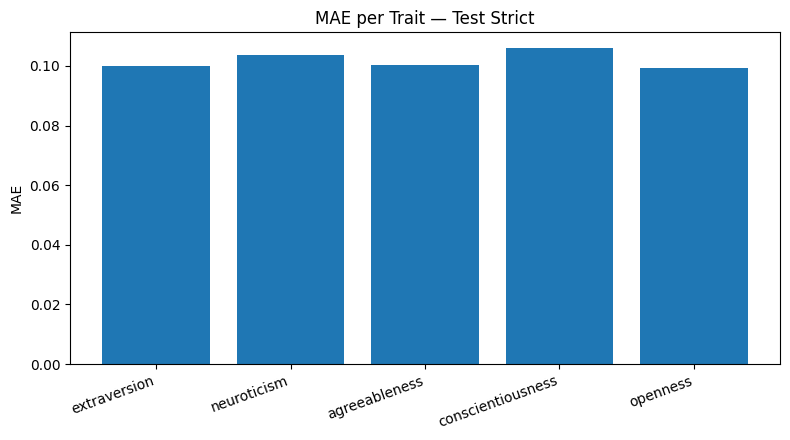

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\metric_bar_rmse.png


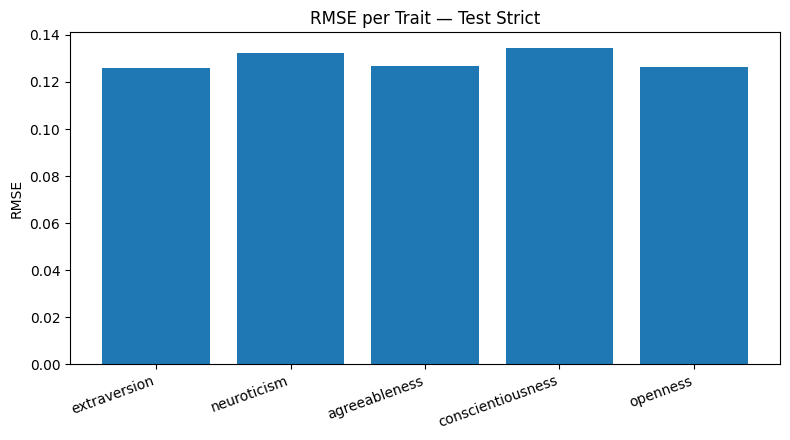

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\metric_bar_r2.png


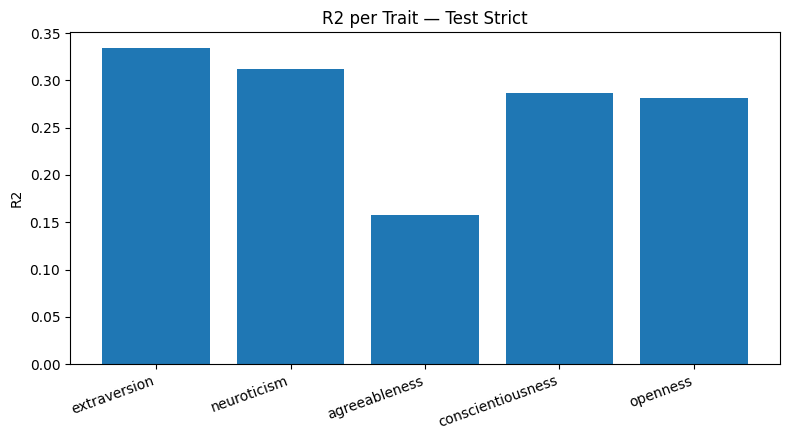

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\metric_bar_pearson.png


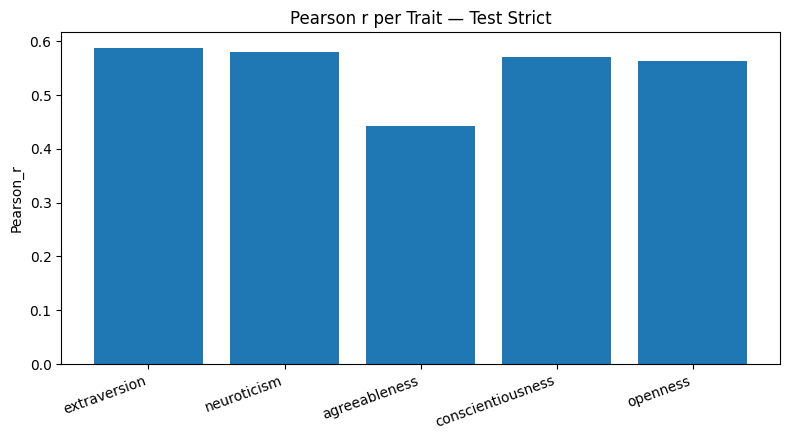

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\hist_extraversion.png


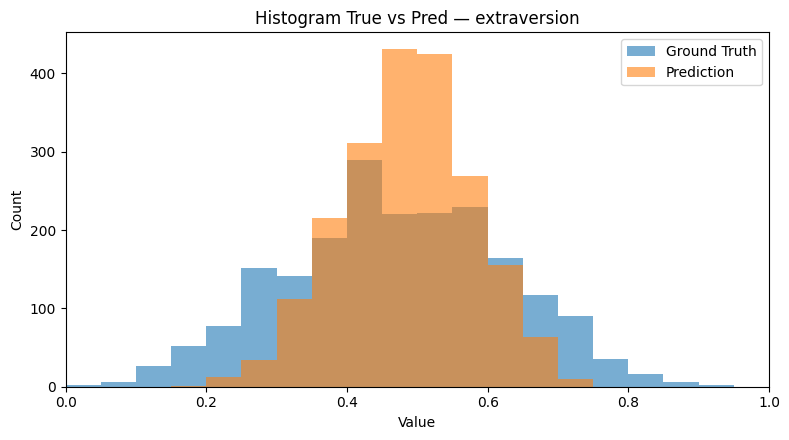

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\hist_neuroticism.png


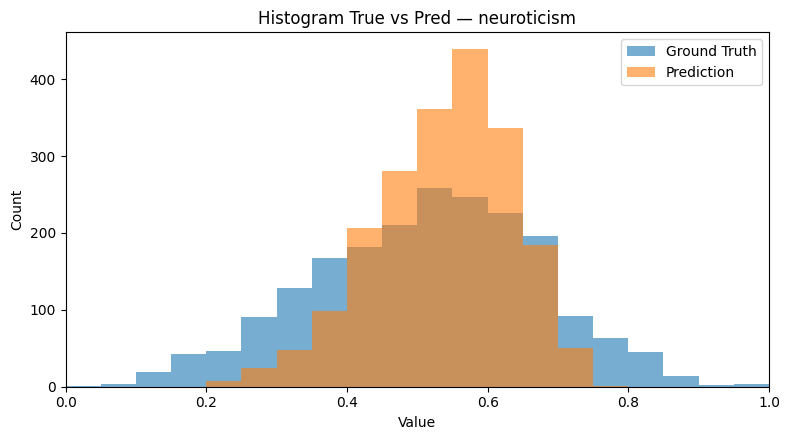

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\hist_agreeableness.png


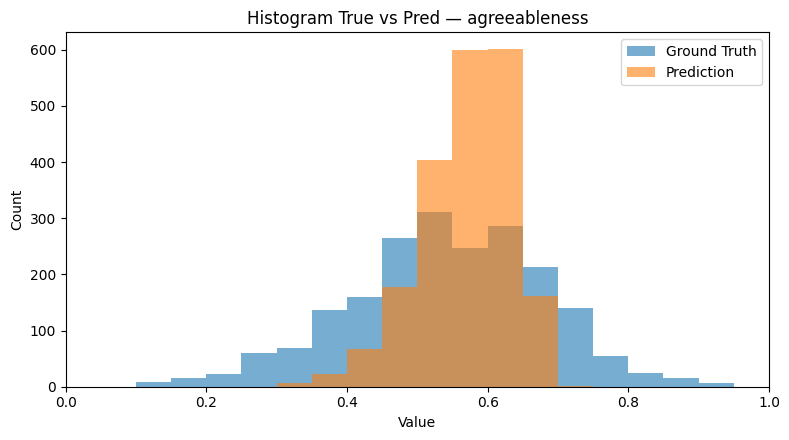

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\hist_conscientiousness.png


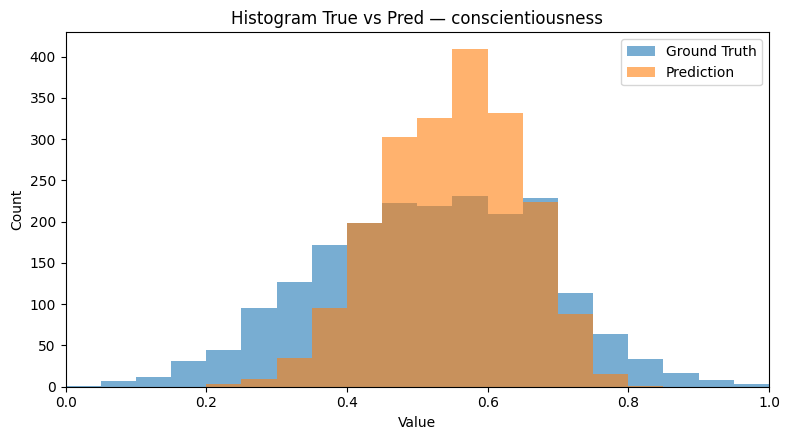

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\hist_openness.png


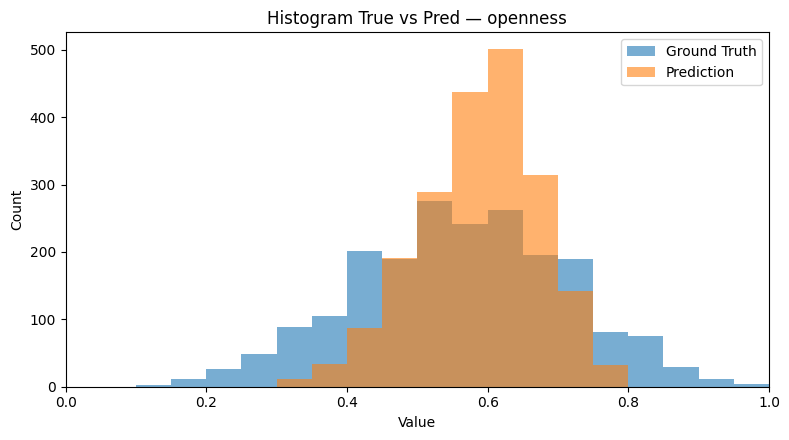

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\scatter_extraversion.png


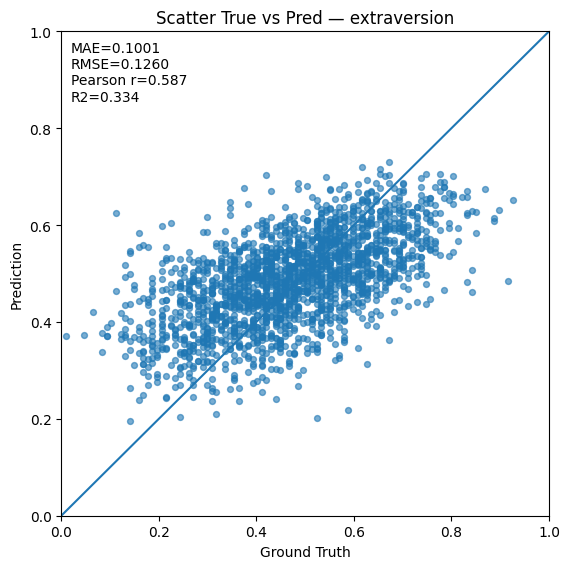

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\scatter_neuroticism.png


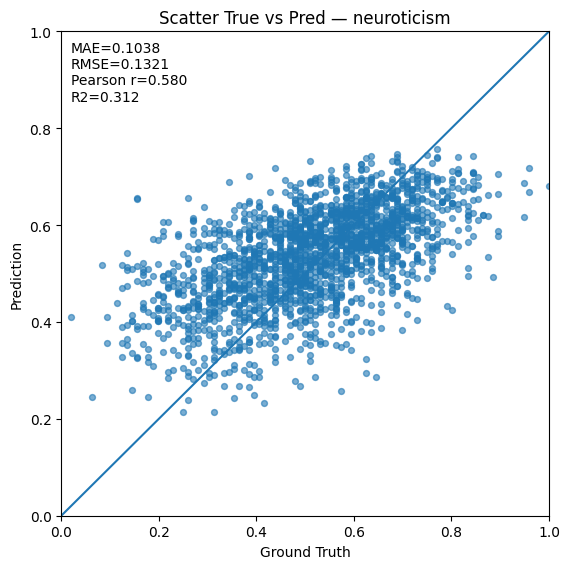

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\scatter_agreeableness.png


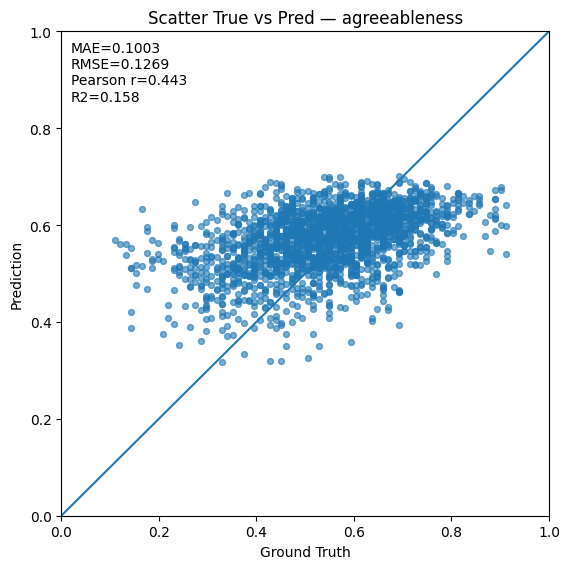

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\scatter_conscientiousness.png


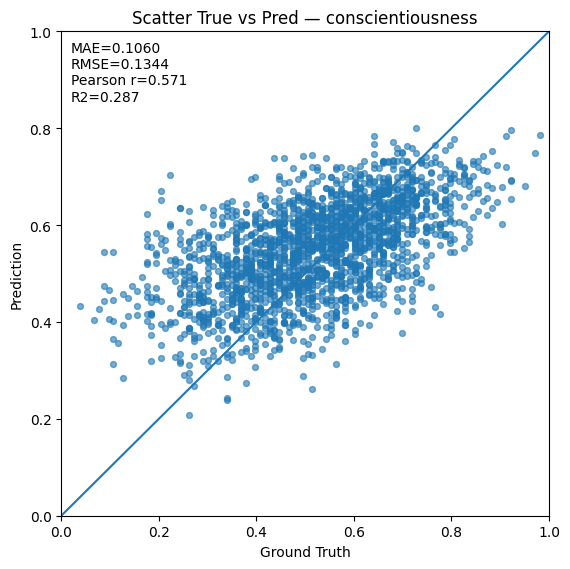

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\scatter_openness.png


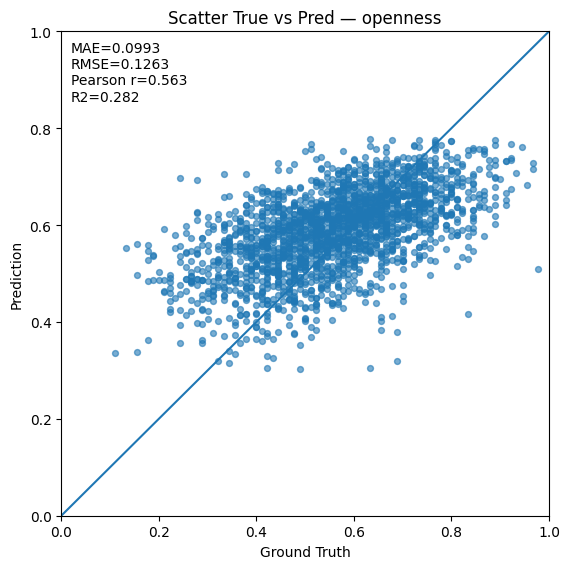

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\residual_hist_extraversion.png


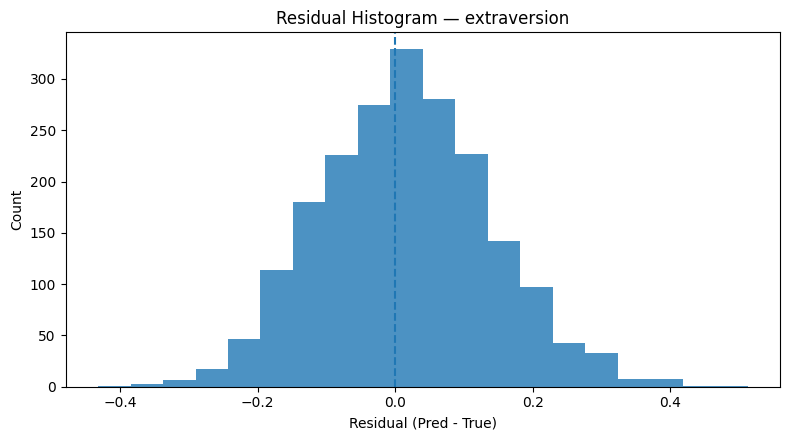

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\residual_hist_neuroticism.png


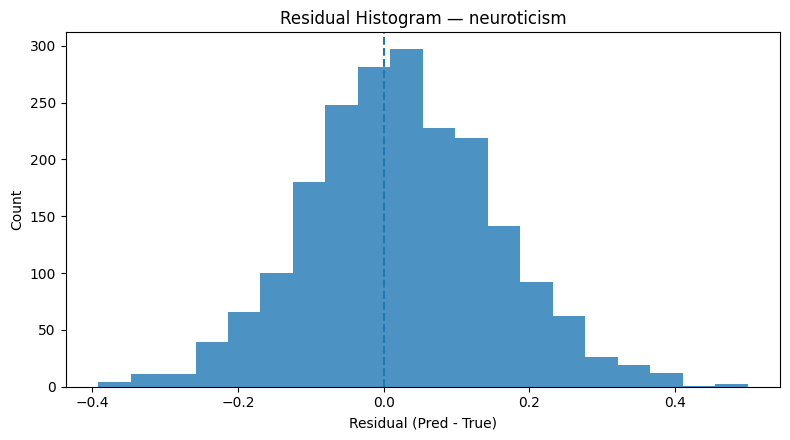

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\residual_hist_agreeableness.png


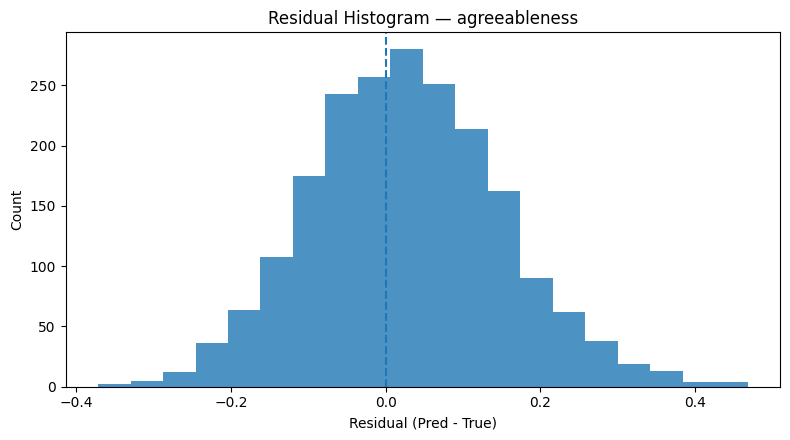

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\residual_hist_conscientiousness.png


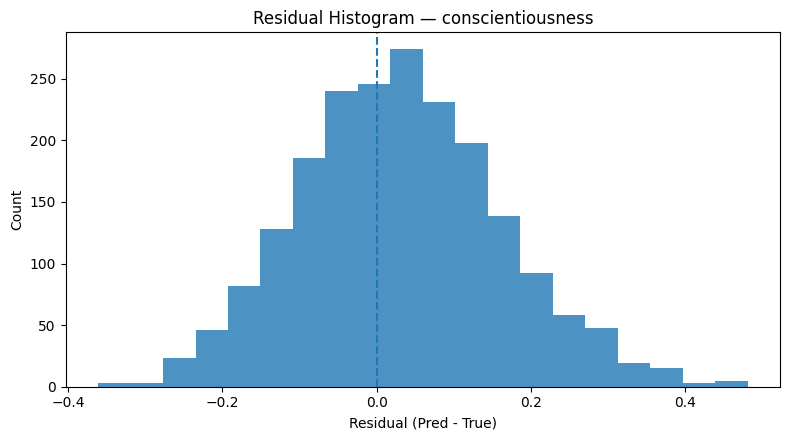

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\residual_hist_openness.png


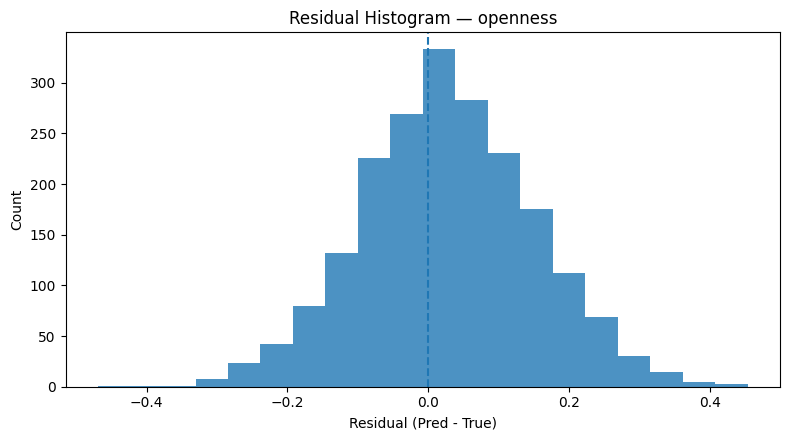

Saved figure: E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\figures\row_mae_distribution.png


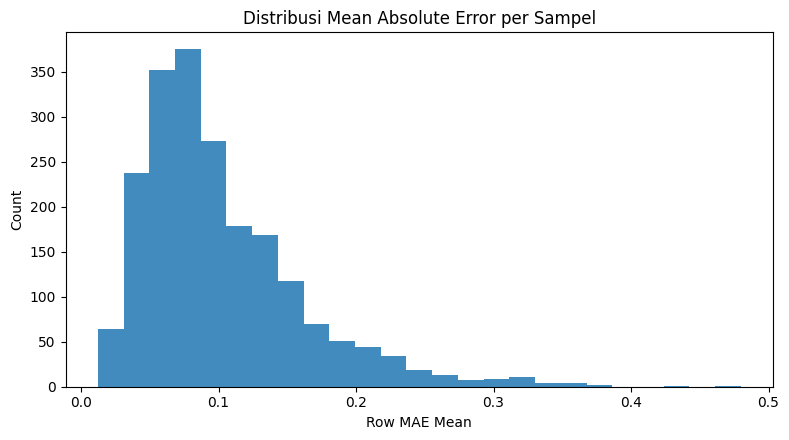

In [8]:
# ============================================================
# RUN VISUALIZATIONS
# ============================================================
plot_metric_bar(df_trait_metrics, "MAE", "MAE per Trait — Test Strict", "metric_bar_mae.png")
plot_metric_bar(df_trait_metrics, "RMSE", "RMSE per Trait — Test Strict", "metric_bar_rmse.png")
plot_metric_bar(df_trait_metrics, "R2", "R2 per Trait — Test Strict", "metric_bar_r2.png")
plot_metric_bar(df_trait_metrics, "Pearson_r", "Pearson r per Trait — Test Strict", "metric_bar_pearson.png")
plot_histograms(y_true, y_pred, TRAITS, bins=BINS, clip=CLIP_RANGE)
plot_scatter(y_true, y_pred, TRAITS, clip=CLIP_RANGE)
plot_residual_histograms(residual, TRAITS, bins=BINS)
plot_row_error_distribution(row_mae_mean)

In [9]:
# ============================================================
# CONTOH SAMPEL TERBAIK & TERBURUK
# ============================================================
best_cols = [c for c in [
    "clip_id", "group_id", "channel_id", "video_id",
    "audio_out", "resolved_audio_path", "mae_row_mean", "rmse_row"
] if c in df_detail.columns]

df_best = df_detail.sort_values("mae_row_mean", ascending=True).head(10).copy()
df_worst = df_detail.sort_values("mae_row_mean", ascending=False).head(10).copy()

best_path = EVAL_OUT / f"top10_best_samples_{RUN_TS}.csv"
worst_path = EVAL_OUT / f"top10_worst_samples_{RUN_TS}.csv"
df_best.to_csv(best_path, index=False)
df_worst.to_csv(worst_path, index=False)

print("Saved top best  :", best_path)
print("Saved top worst :", worst_path)

print("\nTop 10 best samples:")
display(df_best[best_cols] if best_cols else df_best.head(10))

print("\nTop 10 worst samples:")
display(df_worst[best_cols] if best_cols else df_worst.head(10))

Saved top best  : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\top10_best_samples_20260317_161152.csv
Saved top worst : E:\tugas-akhir-qiqi\code\workspaceVastAI\outputs\final_retrain_lr0.0002_r4\eval_test_strict_full_20260317_161152\top10_worst_samples_20260317_161152.csv

Top 10 best samples:


,clip_id,group_id,audio_out,resolved_audio_path,mae_row_mean,rmse_row
317,9c66Lb7e1BQ.002,9c66Lb7e1BQ,output/preprocessing/preprocessed_full/9c66Lb7...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.012133,0.017771
640,JRqhE9jsamU.000,JRqhE9jsamU,output/preprocessing/preprocessed_full/JRqhE9j...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.013000,0.016710
434,Cl5jhuLQ9Dg.002,Cl5jhuLQ9Dg,output/preprocessing/preprocessed_full/Cl5jhuL...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.014729,0.024590
1111,X9AEEGzWSU8.002,X9AEEGzWSU8,output/preprocessing/preprocessed_full/X9AEEGz...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.015777,0.017563
848,PooFvZH6fK0.003,PooFvZH6fK0,output/preprocessing/preprocessed_full/PooFvZH...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.015798,0.017499
989,TEGJrmNFvXY.000,TEGJrmNFvXY,output/preprocessing/preprocessed_full/TEGJrmN...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.015952,0.022991
821,PReOtefm17s.003,PReOtefm17s,output/preprocessing/preprocessed_full/PReOtef...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.016789,0.019977
1579,kQ8HhrysfaA.005,kQ8HhrysfaA,output/preprocessing/preprocessed_full/kQ8Hhry...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.017719,0.021817
1728,oGa05H9UXxU.004,oGa05H9UXxU,output/preprocessing/preprocessed_full/oGa05H9...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.018530,0.026689
887,QpA0gj1y6KE.002,QpA0gj1y6KE,output/preprocessing/preprocessed_full/QpA0gj1...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.019131,0.021810



Top 10 worst samples:


,clip_id,group_id,audio_out,resolved_audio_path,mae_row_mean,rmse_row
1530,j3jdT1V-DeI.004,j3jdT1V-DeI,output/preprocessing/preprocessed_full/j3jdT1V...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.479891,0.480407
1531,j3jdT1V-DeI.005,j3jdT1V-DeI,output/preprocessing/preprocessed_full/j3jdT1V...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.431902,0.434676
1001,TNtcyfM9jak.002,TNtcyfM9jak,output/preprocessing/preprocessed_full/TNtcyfM...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.378860,0.389476
1389,f7togdqxEoo.004,f7togdqxEoo,output/preprocessing/preprocessed_full/f7togdq...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.378764,0.383313
1526,j3jdT1V-DeI.000,j3jdT1V-DeI,output/preprocessing/preprocessed_full/j3jdT1V...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.360820,0.362319
644,Jv2lyDcOmEM.002,Jv2lyDcOmEM,output/preprocessing/preprocessed_full/Jv2lyDc...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.360111,0.362690
109,2q7ZwMoPvok.000,2q7ZwMoPvok,output/preprocessing/preprocessed_full/2q7ZwMo...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.354705,0.357273
9,-R2SZu3SYgM.001,-R2SZu3SYgM,output/preprocessing/preprocessed_full/-R2SZu3...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.352969,0.356679
1386,f7togdqxEoo.001,f7togdqxEoo,output/preprocessing/preprocessed_full/f7togdq...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.346208,0.351145
1527,j3jdT1V-DeI.001,j3jdT1V-DeI,output/preprocessing/preprocessed_full/j3jdT1V...,E:\tugas-akhir-qiqi\output\preprocessing\prepr...,0.338304,0.342167


## File output yang dihasilkan

Semua file tersimpan di folder:

`FINAL_RUN_DIR / eval_test_strict_full_<timestamp>/`

Isi utamanya:

- `pred_detail_test_strict_full_<timestamp>.csv`  
  Detail lengkap per sampel: metadata, ground truth, prediksi, residual, absolute error, squared error, dan row-level MAE/RMSE.
- `metrics_per_trait_<timestamp>.csv`  
  Ringkasan metrik lengkap per trait.
- `metrics_overall_<timestamp>.csv`  
  Ringkasan metrik agregat seluruh test set.
- `mae_summary_compat_<timestamp>.csv`  
  Format kompatibel dengan notebook `TestPersebaran.ipynb`.
- `top10_best_samples_<timestamp>.csv`
- `top10_worst_samples_<timestamp>.csv`
- folder `figures/`  
  Berisi semua plot yang dihasilkan dalam format PNG.

Kalau kamu mau, notebook ini nanti bisa aku lanjutkan lagi dengan versi yang **langsung menyesuaikan nama run terbaikmu secara otomatis** dari folder output yang ada, misalnya berdasarkan `report.json` atau folder `final_retrain_*` tertentu.